In [1]:
import os
import json
import random

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_curve,
    auc
)

import torch
import torch.nn as nn
import torchvision.models as models
from torch.utils.data import Dataset, DataLoader

In [2]:
rlvs_path = '/kaggle/input/datasets/mohamedmustafa/real-life-violence-situations-dataset/Real Life Violence Dataset'
hockey_path = '/kaggle/input/datasets/seldaertrk/hockey-fight/data'
scvd_path = '/kaggle/input/datasets/toluwaniaremu/smartcity-cctv-violence-detection-dataset-scvd/SCVD/SCVD_converted/Test'

print(f"RLVS: {os.listdir(rlvs_path)}")
print(f"hockey Fights: {os.listdir(hockey_path)}")
print(f"SCVD: {os.listdir(scvd_path)}")

RLVS: ['NonViolence', 'Violence']
hockey Fights: ['nofights', 'fights']
SCVD: ['Weaponized', 'Normal', 'Violence']


In [3]:
DATASET_CONFIG = {
    "rlvs": {
        "root": rlvs_path,
        "classes": {
            "Violence": 1,
            "NonViolence": 0
        }
    },
    "hockey": {
        "root": hockey_path,
        "classes": {
            "fights": 1,
            "nofights": 0
        }
    },
    "scvd": {
        "root": scvd_path,
        "classes": {
            "Violence": 1, 
            "Normal": 0, 
            "Weaponized": 1
        }
    }
}

In [4]:
def get_video_files(root_dir, extensions=(".avi", ".mp4")):
    video_files = []
    for root, _, files in os.walk(root_dir):
        for f in files:
            if f.lower().endswith(extensions):
                video_files.append(os.path.join(root, f))
    return video_files


def build_dataframe(dataset_names):
    data = []
    for name in dataset_names:
        cfg = DATASET_CONFIG[name]
        for class_name, label in cfg["classes"].items():
            folder = os.path.join(cfg["root"], class_name)
            videos = get_video_files(folder)
            for path in videos:
                data.append({"path": path, "label": label, "source": name})
    return pd.DataFrame(data)


def split_dataframe(df, test_size=0.2, val_size=0.5, seed=42):
    train_df, temp_df = train_test_split(
        df, 
        test_size=test_size, 
        stratify=df["label"], 
        random_state=seed
    )
    val_df, test_df = train_test_split(
        temp_df, 
        test_size=1 - val_size, 
        stratify=temp_df["label"], 
        random_state=seed
    )
    return train_df.reset_index(drop=True), \
           val_df.reset_index(drop=True), \
           test_df.reset_index(drop=True)

In [5]:
OUTLIER_VIDEOS = [
    "NV_992.mp4",
    "V_789.mp4",
    "V_398.mp4"
]


def remove_outliers(df):
    mask = ~(
        (df["source"] == "rlvs") &
        (df["path"].apply(lambda x: os.path.basename(x) in OUTLIER_VIDEOS))
    )
    return df[mask].reset_index(drop=True)

In [6]:
def sample_frames(total_frames, n_frames):
    if total_frames <= n_frames:
        indices = np.linspace(0, total_frames - 1, total_frames)
        indices = np.pad(indices, (0, n_frames - total_frames), mode="edge")
    else:
        indices = np.linspace(0, total_frames - 1, n_frames)
    return indices.astype(int)

In [7]:
class ViolenceVideoDataset(Dataset):
    def __init__(self, dataframe, n_frames=1, resize_size=(224, 224), transforms=False):
        self.df = dataframe.reset_index(drop=True)
        self.n_frames = n_frames
        self.resize_size = resize_size
        self.transforms = transforms

        self.mean = np.array([0.485, 0.456, 0.406])
        self.std = np.array([0.229, 0.224, 0.225])

    def __len__(self):
        return len(self.df)

    def _get_frames(self, video_path, deterministic=False):
        cap = cv2.VideoCapture(video_path)
    
        total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        fps = cap.get(cv2.CAP_PROP_FPS)
    
        if total_frames <= 0:
            cap.release()
            return np.zeros((self.n_frames, *self.resize_size, 3), dtype=np.float32)
    
        # --- визначаємо вікно ---
        window_size = int(3 * fps)
        window_size = min(window_size, total_frames)
    
        if deterministic:
            start = (total_frames - window_size) // 2
        else:
            start = random.randint(0, max(0, total_frames - window_size))
    
        end = start + window_size

        # --- беремо кадри всередині вікна ---
        indices = np.linspace(start, end - 1, self.n_frames).astype(int)
    
        frames = []
        current_frame = 0
        target_set = set(indices)
        
        while True:
            ret, frame = cap.read()
            if not ret or frame is None:
                continue
        
            if current_frame in target_set:
                frame = cv2.resize(frame, self.resize_size)
                frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
                frames.append(frame)
        
            current_frame += 1
        
            if len(frames) == len(indices):
                break
        if len(frames) == 0:
            return np.zeros((self.n_frames, *self.resize_size, 3), dtype=np.float32)
    
        cap.release()
        return np.stack(frames)


    def _preprocess(self, frames):
        frames = frames.astype(np.float32) / 255.0
        frames = (frames - self.mean) / self.std
        frames = torch.from_numpy(frames)
        frames = frames.permute(0, 3, 1, 2)
        return frames
    
    
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        frames = self._get_frames(row.path)
        
        if self.transforms and random.random() < 0.5:
            frames = frames[:, :, ::-1, :]  # flip

        frames = self._preprocess(frames)
        label = torch.tensor(row.label).float()
        return frames, label

In [8]:
def build_loaders(train_df, val_df, test_df, n_frames=32, batch_size=16):
    train_loader = DataLoader(
        ViolenceVideoDataset(train_df, n_frames, transforms=True),
        batch_size=batch_size,
        shuffle=True,
        num_workers=2,
        pin_memory=True,
        persistent_workers=True
    )

    val_loader = DataLoader(
        ViolenceVideoDataset(val_df, n_frames),
        batch_size=batch_size,
        shuffle=False,
        num_workers=2,
        pin_memory=True,
        persistent_workers=True
    )

    test_loader = DataLoader(
        ViolenceVideoDataset(test_df, n_frames),
        batch_size=batch_size,
        shuffle=False,
        num_workers=2,
        pin_memory=True,
        persistent_workers=True
    )

    return train_loader, val_loader, test_loader

In [9]:
def get_model(model_type):
    if model_type == "cnn+lstm":
        return CNNLSTM(freeze_cnn=True, unfreeze_last_k=3)
    else:
        raise ValueError("Unknown model type")


def get_models():
    return {
        "CNN+LSTM": get_model("cnn+lstm"),
    }


class CNNLSTM(nn.Module):
    def __init__(
        self,
        hidden_dim=128,
        num_layers=1,
        bidirectional=False,
        freeze_cnn=False,
        unfreeze_last_k=5,
        temporal_pooling=True       # True → середнє по часу, False → останній hidden
    ):
        super().__init__()

        backbone = models.mobilenet_v2(weights="IMAGENET1K_V1")
        self.cnn = backbone.features
        self.pool = nn.AdaptiveAvgPool2d((1, 1))

        if freeze_cnn:
            for p in self.cnn.parameters():
                p.requires_grad = False
        
        if unfreeze_last_k > 0:
            for layer in list(self.cnn.children())[-unfreeze_last_k:]:
                for p in layer.parameters():
                    p.requires_grad = True

        self.lstm = nn.LSTM(
            input_size=1280,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=bidirectional,
            dropout=0.3 if num_layers > 1 else 0.0
        )

        self.temporal_pooling = temporal_pooling
        lstm_out_dim = hidden_dim * (2 if bidirectional else 1)

        self.classifier = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(lstm_out_dim, 1)
        )

    def forward(self, x):
        """
        x: [B, T, C, H, W]
        """
        B, T, C, H, W = x.shape

        x = x.view(B * T, C, H, W)
        x = self.cnn(x)
        x = self.pool(x)
        x = x.view(B, T, -1)  # [B, T, 1280]

        lstm_out, (h_n, _) = self.lstm(x)

        if self.temporal_pooling:
            feat = lstm_out.mean(dim=1)
        else:
            feat = h_n[-1]

        logits = self.classifier(feat)
        return logits

In [10]:
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


def train_model(model, train_loader, val_loader, device, epochs=5, lr=1e-4):
    model = model.to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.BCEWithLogitsLoss()

    scaler = torch.cuda.amp.GradScaler()

    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

    best_val_loss = float("inf")
    best_state = None

    for epoch in range(epochs):
        model.train()
        train_loss, train_correct = 0, 0

        train_pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} [Train]")

        for frames, labels in train_pbar:
            frames = frames.to(device, non_blocking=True).float()
            labels = labels.to(device, non_blocking=True).float().view(-1, 1)

            optimizer.zero_grad(set_to_none=True)

            with torch.cuda.amp.autocast():
                logits = model(frames)
                loss = criterion(logits, labels)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            train_loss += loss.item()

            probs = torch.sigmoid(logits)
            preds = (probs >= 0.5).float()
            train_correct += (preds == labels).sum().item()

            train_pbar.set_postfix({'loss': loss.item()})

        model.eval()
        val_loss, val_correct = 0, 0

        with torch.no_grad():
            for frames, labels in val_loader:
                frames = frames.to(device, non_blocking=True).float()
                labels = labels.to(device, non_blocking=True).float().view(-1, 1)

                with torch.cuda.amp.autocast():
                    logits = model(frames)
                    loss = criterion(logits, labels)

                val_loss += loss.item()

                probs = torch.sigmoid(logits)
                preds = (probs >= 0.5).float()
                val_correct += (preds == labels).sum().item()

        t_loss = train_loss / len(train_loader)
        t_acc = train_correct / len(train_loader.dataset)

        v_loss = val_loss / len(val_loader)
        v_acc = val_correct / len(val_loader.dataset)

        history['train_loss'].append(t_loss)
        history['train_acc'].append(t_acc)
        history['val_loss'].append(v_loss)
        history['val_acc'].append(v_acc)

        print(f"Summary -> Train Acc: {t_acc:.4f}, Val Acc: {v_acc:.4f}")

        if v_loss < best_val_loss:
            best_val_loss = v_loss
            best_state = model.state_dict()

    model.load_state_dict(best_state)
    return model, history

In [11]:
def evaluate_model(model, dataloader, device):
    model.eval()
    
    all_probs = []
    all_labels = []
    
    with torch.no_grad():
        for frames, labels in dataloader:
            frames = frames.to(device).float()
            
            logits = model(frames)
            probs = torch.sigmoid(logits)
            
            all_probs.extend(probs.cpu().numpy().reshape(-1))
            all_labels.extend(labels.cpu().numpy().reshape(-1))
    
    y_true = np.array(all_labels).astype(int)
    y_probs = np.array(all_probs)
    
    return y_true, y_probs

In [12]:
def compute_metrics(y_true, y_probs, threshold=0.5):
    y_pred = (y_probs >= threshold).astype(int)
    
    metrics = {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred),
        "recall": recall_score(y_true, y_pred),
        "f1": f1_score(y_true, y_pred),
        "confusion_matrix": confusion_matrix(y_true, y_pred)
    }
    
    fpr, tpr, _ = roc_curve(y_true, y_probs)
    metrics["fpr"] = fpr
    metrics["tpr"] = tpr
    metrics["roc_auc"] = auc(fpr, tpr)
    
    return metrics


def plot_confusion_matrix(cm, class_names=("Non-Violence", "Violence"), save_path=None, show=True):
    plt.figure(figsize=(6, 5))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=class_names,
        yticklabels=class_names
    )
    plt.xlabel("Predicted label")
    plt.ylabel("True label")
    plt.title("Confusion Matrix")
    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path)
    if show:
        plt.show()
    plt.close()

def plot_roc_curve(fpr, tpr, roc_auc, save_path=None, show=True):
    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, label=f"ROC curve (AUC = {roc_auc:.4f})")
    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve")
    
    plt.legend(loc="lower right")
    
    plt.grid(True)
    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path)

    if show:
        plt.show()
    
    plt.close()


def plot_training_curves(history, save_path=None, show=True):
    epochs = range(1, len(history['train_loss']) + 1)
    
    plt.figure(figsize=(12, 5))
    
    # Loss
    plt.subplot(1, 2, 1)
    plt.plot(epochs, history['train_loss'], label="Train Loss")
    plt.plot(epochs, history['val_loss'], label="Val Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training and Validation Loss")
    plt.legend()
    
    # Accuracy
    plt.subplot(1, 2, 2)
    plt.plot(epochs, history['train_acc'], label="Train Accuracy")
    plt.plot(epochs, history['val_acc'], label="Val Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title("Training and Validation Accuracy")
    plt.legend()
    
    plt.tight_layout()
    if save_path is not None:
        plt.savefig(save_path)
    if show:
        plt.show()
    plt.close()

In [13]:
def run_single_experiment(model, model_name, 
                          train_loader, val_loader, 
                          test_loader, device, 
                          save_dir, epochs):
    os.makedirs(save_dir, exist_ok=True)
    model, history = train_model(model, train_loader, 
                                 val_loader, device, epochs)
    torch.save(model.state_dict(), os.path.join(save_dir,"model.pt"))
    plot_training_curves(history, os.path.join(save_dir,"training_curves.png"))

    with open(os.path.join(save_dir,"history.json"),"w") as f:
        json.dump(history,f)

    results = {}
    for split_name, loader in {
        "val": val_loader,
        "test": test_loader
    }.items():
        y_true, y_probs = evaluate_model(model, loader, device)
        metrics = compute_metrics(y_true,y_probs)
        results[split_name] = {
            "accuracy": metrics["accuracy"],
            "precision": metrics["precision"],
            "recall": metrics["recall"],
            "f1": metrics["f1"],
            "roc_auc": metrics["roc_auc"]
        }
        print(f"\n=== {split_name.upper()} METRICS ===")
        print(f"Accuracy : {metrics['accuracy']:.4f}")
        print(f"Precision: {metrics['precision']:.4f}")
        print(f"Recall   : {metrics['recall']:.4f}")
        print(f"F1-score : {metrics['f1']:.4f}")
        print(f"ROC AUC  : {metrics['roc_auc']:.4f}")
        plot_confusion_matrix(metrics["confusion_matrix"],
                    save_path=os.path.join(save_dir, f"{split_name}_cm.png")
    )
        plot_roc_curve(metrics["fpr"], metrics["tpr"], 
                       metrics["roc_auc"], 
                       os.path.join(save_dir,f"{split_name}_roc.png"))
    with open(os.path.join(save_dir,"metrics.json"),"w") as f:
        json.dump(results,f,indent=4)
    return results

In [14]:
def run_experiment(train_df, val_df, test_df, 
                   device, epochs=5, seeds=(42,43,44)):
    results_all = {}
    loaders = build_loaders(train_df, val_df, test_df)
    train_loader, val_loader, test_loader = loaders

    for seed in seeds:
        print(f"\nSeed {seed}")
        set_seed(seed)
        models_dict = get_models()

        for model_name, model in models_dict.items():
            print(f"\nModel {model_name}")
            save_dir = f"./experiments/{model_name}/seed_{seed}"
            results = run_single_experiment(
                model, model_name, train_loader, 
                val_loader, test_loader, device, 
                save_dir, epochs)

            results_all[(model_name,seed)] = results
    return results_all

In [15]:
def prepare_dataset_splits(dataset_names, test_dataset=None, seed=42, val_size=0.2):
    df = build_dataframe(dataset_names)
    df = remove_outliers(df)

    if test_dataset:
        df_test = build_dataframe([test_dataset])
        df_test = remove_outliers(df_test)
    else:
        df_test = None

    train_df, val_df, temp_df = split_dataframe(df, test_size=val_size, val_size=0.5, seed=seed)
    test_df = df_test if df_test is not None else temp_df
    return train_df, val_df, test_df

In [16]:
def run_scenario(model_name, train_datasets, 
                 test_dataset=None, device="cpu", 
                 epochs=5, n_frames=16, batch_size=8, seeds=(42,43,44)):
    results_all = {}
    for seed in seeds:
        print(f"\n=== Seed {seed} ===")
        
        set_seed(seed)
        train_df, val_df, test_df = prepare_dataset_splits(train_datasets, test_dataset, seed)
        train_loader, val_loader, test_loader = build_loaders(train_df, val_df, test_df, n_frames=16, batch_size=8)
        
        model = get_model(model_name)
        
        save_dir = f"./experiments/{model_name}_{'_'.join(train_datasets)}_seed_{seed}"
        
        results = run_single_experiment(model, model_name, train_loader,val_loader,test_loader,device,save_dir,epochs)
        results_all[(model_name,seed)] = results
    return results_all


def cross_validation_splits(df, n_splits=5, seed=42):
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)
    splits = []
    X = df.index.values
    y = df.label.values
    for train_idx,val_idx in skf.split(X, y):
        train_df = df.iloc[train_idx].reset_index(drop=True)
        val_df = df.iloc[val_idx].reset_index(drop=True)
        splits.append((train_df, val_df))
    return splits



========== MODEL: cnn+lstm ==========

--- Scenario: Combined_RLVS_Hockey_to_SCVD ---

=== Seed 44 ===
Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 194MB/s]
/tmp/ipykernel_24/1967065897.py:14: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()


Epoch 1/5 [Train]:   0%|          | 0/300 [00:00<?, ?it/s]

/tmp/ipykernel_24/1967065897.py:33: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
/tmp/ipykernel_24/1967065897.py:57: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Summary -> Train Acc: 0.8703, Val Acc: 0.9700


...

[h264 @ 0x3301ab80] mb_type 104 in P slice too large at 98 31
[h264 @ 0x3301ab80] error while decoding MB 98 31


Summary -> Train Acc: 0.9437, Val Acc: 0.9700


Epoch 5/5 [Train]:   0%|          | 0/300 [00:00<?, ?it/s]

[h264 @ 0x3301e080] mb_type 104 in P slice too large at 98 31
[h264 @ 0x3301e080] error while decoding MB 98 31


Summary -> Train Acc: 0.9499, Val Acc: 0.9800


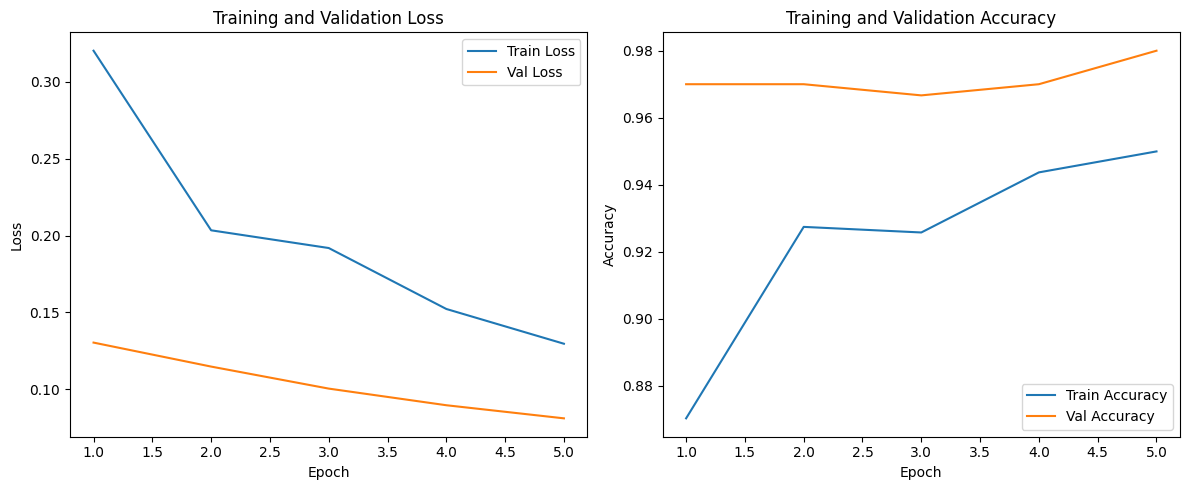


=== VAL METRICS ===
Accuracy : 0.9767
Precision: 0.9799
Recall   : 0.9733
F1-score : 0.9766
ROC AUC  : 0.9972


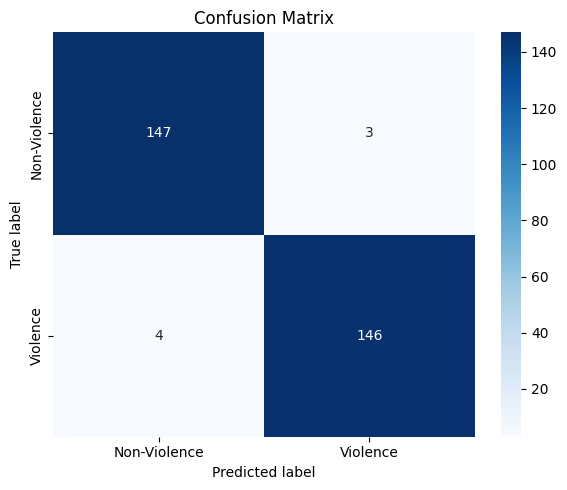

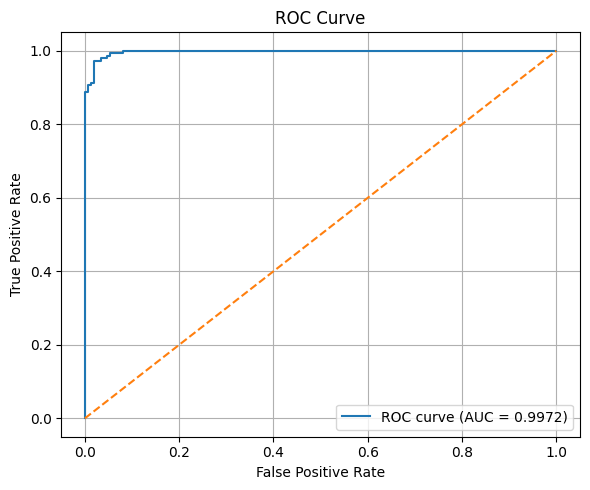


=== TEST METRICS ===
Accuracy : 0.8537
Precision: 0.9286
Recall   : 0.7222
F1-score : 0.8125
ROC AUC  : 0.8708


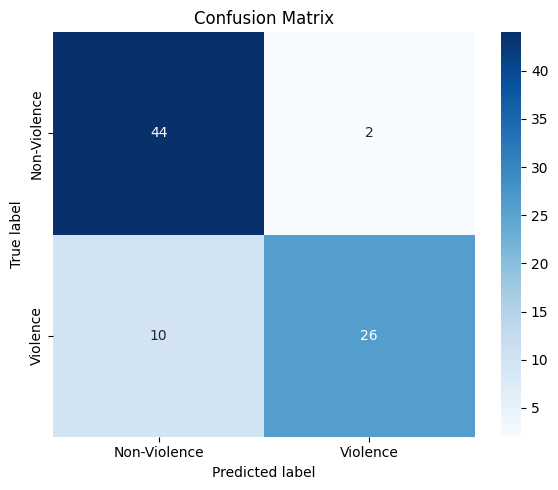

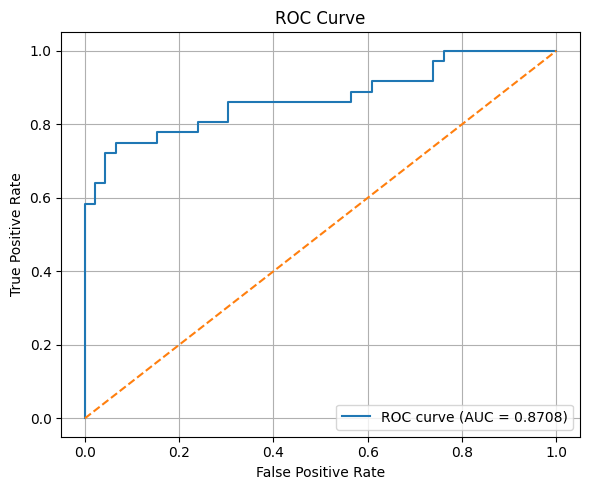


--- Scenario: RLVS_train ---

=== Seed 44 ===


/tmp/ipykernel_24/1967065897.py:14: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()


Epoch 1/5 [Train]:   0%|          | 0/200 [00:00<?, ?it/s]

/tmp/ipykernel_24/1967065897.py:33: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
[h264 @ 0x43f76440] mb_type 104 in P slice too large at 98 31
[h264 @ 0x43f76440] error while decoding MB 98 31
/tmp/ipykernel_24/1967065897.py:57: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Summary -> Train Acc: 0.8729, Val Acc: 0.9450


...

Epoch 4/5 [Train]:   0%|          | 0/200 [00:00<?, ?it/s]

[h264 @ 0x44d7f040] mb_type 104 in P slice too large at 98 31
[h264 @ 0x44d7f040] error while decoding MB 98 31


Summary -> Train Acc: 0.9399, Val Acc: 0.9250


Epoch 5/5 [Train]:   0%|          | 0/200 [00:00<?, ?it/s]

Summary -> Train Acc: 0.9599, Val Acc: 0.9550


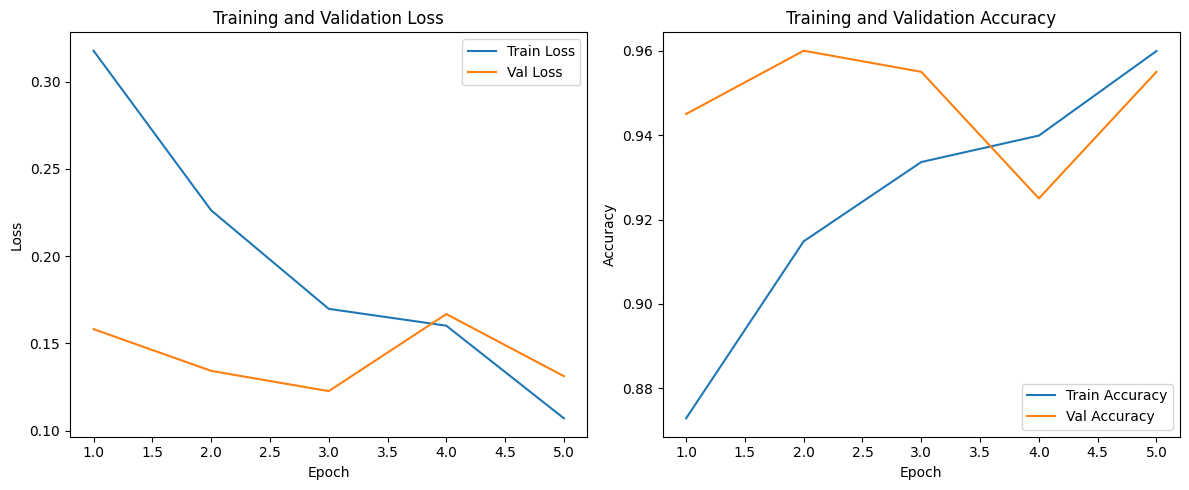


=== VAL METRICS ===
Accuracy : 0.9450
Precision: 0.9083
Recall   : 0.9900
F1-score : 0.9474
ROC AUC  : 0.9949


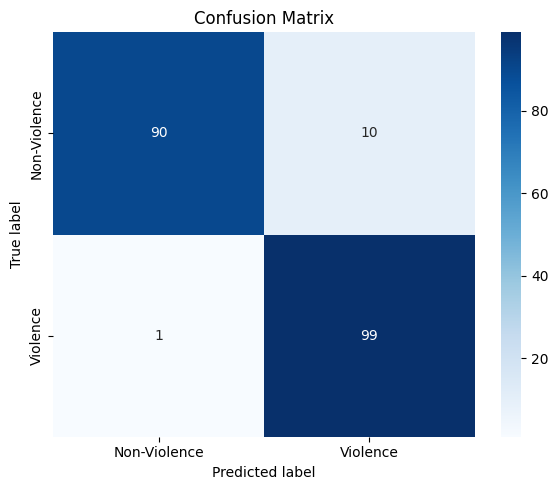

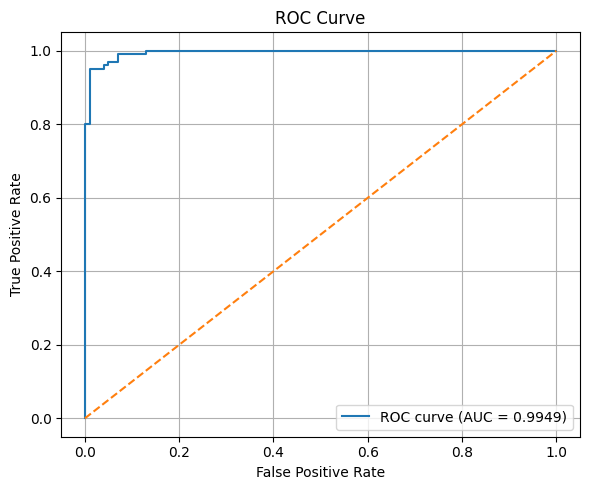

[h264 @ 0x44d76e40] mb_type 104 in P slice too large at 98 31
[h264 @ 0x44d76e40] error while decoding MB 98 31



=== TEST METRICS ===
Accuracy : 0.9730
Precision: 0.9600
Recall   : 0.9870
F1-score : 0.9733
ROC AUC  : 0.9982


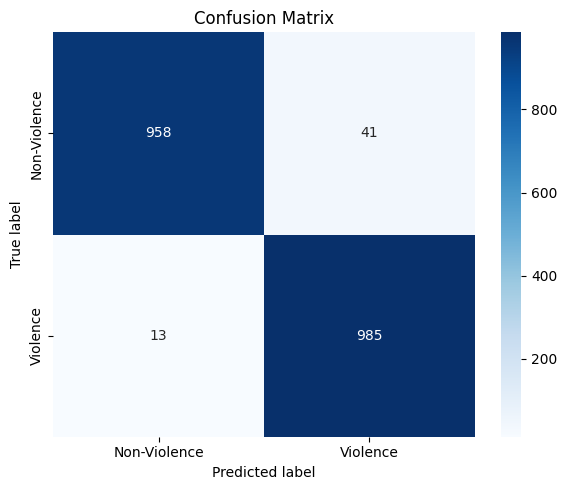

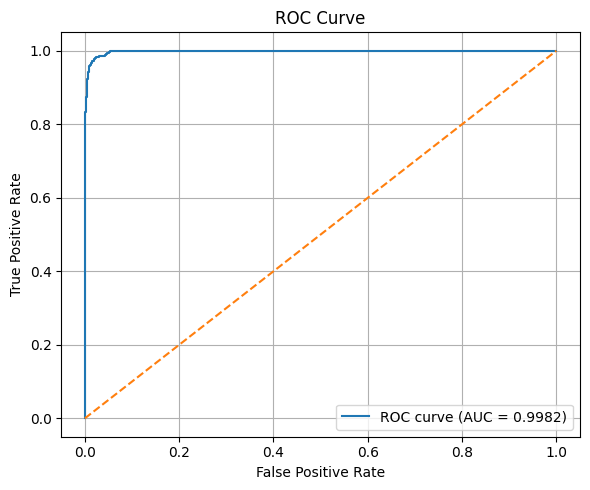


--- Scenario: Hockey_train ---

=== Seed 44 ===


/tmp/ipykernel_24/1967065897.py:14: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()


Epoch 1/5 [Train]:   0%|          | 0/100 [00:00<?, ?it/s]

/tmp/ipykernel_24/1967065897.py:33: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
/tmp/ipykernel_24/1967065897.py:57: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Summary -> Train Acc: 0.8925, Val Acc: 0.9400


...

Summary -> Train Acc: 0.9313, Val Acc: 0.9400


Epoch 4/5 [Train]:   0%|          | 0/100 [00:00<?, ?it/s]

Summary -> Train Acc: 0.9587, Val Acc: 0.9500


Epoch 5/5 [Train]:   0%|          | 0/100 [00:00<?, ?it/s]

Summary -> Train Acc: 0.9725, Val Acc: 0.9600


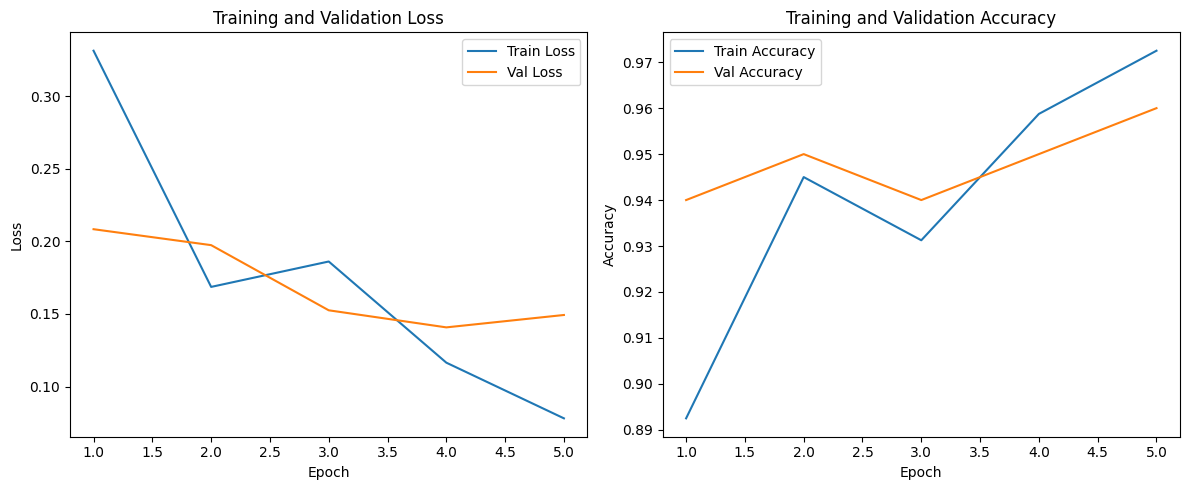


=== VAL METRICS ===
Accuracy : 0.9600
Precision: 0.9259
Recall   : 1.0000
F1-score : 0.9615
ROC AUC  : 0.9864


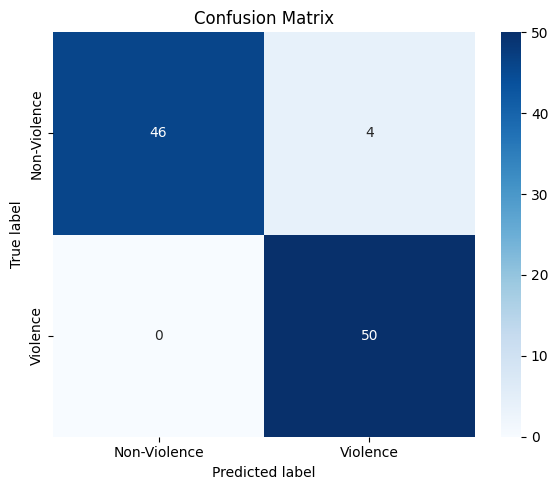

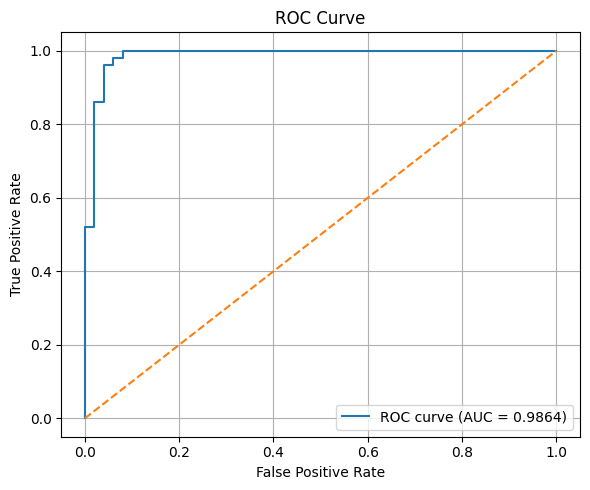


=== TEST METRICS ===
Accuracy : 0.9840
Precision: 0.9802
Recall   : 0.9880
F1-score : 0.9841
ROC AUC  : 0.9979


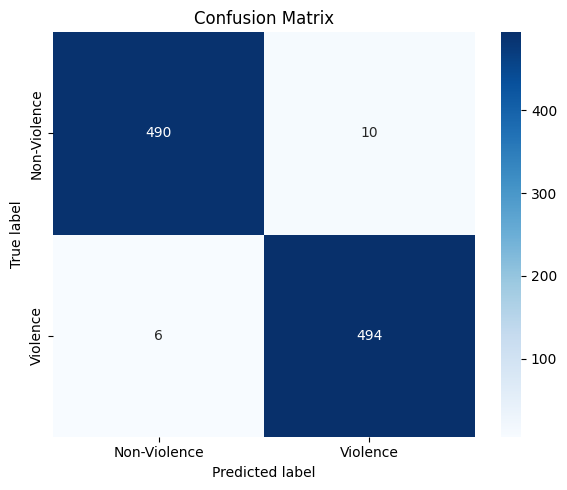

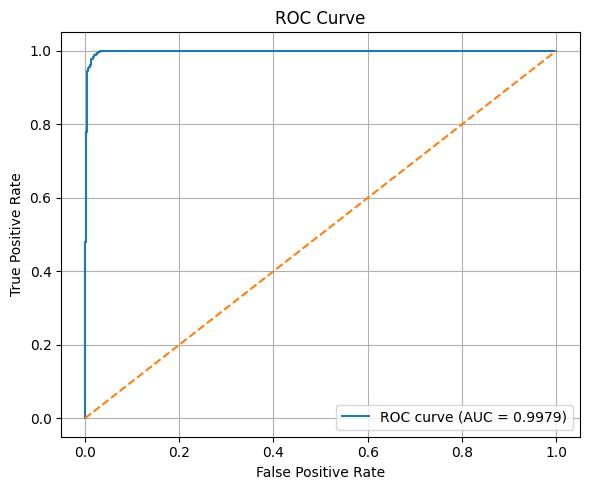


--- Scenario: RLVS_to_Hockey ---

=== Seed 44 ===


/tmp/ipykernel_24/1967065897.py:14: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()


Epoch 1/5 [Train]:   0%|          | 0/200 [00:00<?, ?it/s]

/tmp/ipykernel_24/1967065897.py:33: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
[h264 @ 0x42bf3580] mb_type 104 in P slice too large at 98 31
[h264 @ 0x42bf3580] error while decoding MB 98 31
/tmp/ipykernel_24/1967065897.py:57: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Summary -> Train Acc: 0.8729, Val Acc: 0.9450


...

Epoch 4/5 [Train]:   0%|          | 0/200 [00:00<?, ?it/s]

[h264 @ 0x4592eb40] mb_type 104 in P slice too large at 98 31
[h264 @ 0x4592eb40] error while decoding MB 98 31


Summary -> Train Acc: 0.9430, Val Acc: 0.9300


Epoch 5/5 [Train]:   0%|          | 0/200 [00:00<?, ?it/s]

Summary -> Train Acc: 0.9624, Val Acc: 0.9550


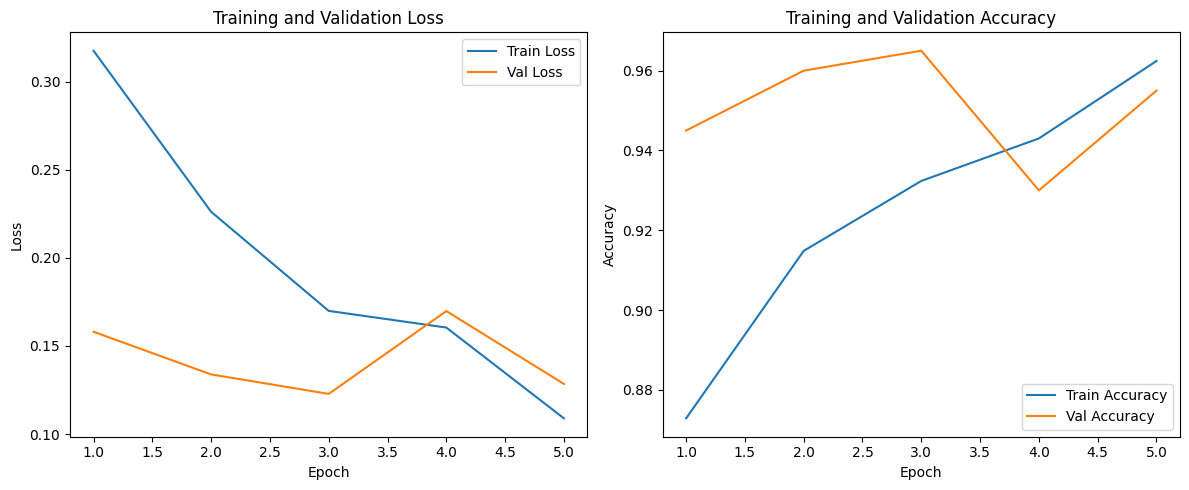


=== VAL METRICS ===
Accuracy : 0.9500
Precision: 0.9167
Recall   : 0.9900
F1-score : 0.9519
ROC AUC  : 0.9946


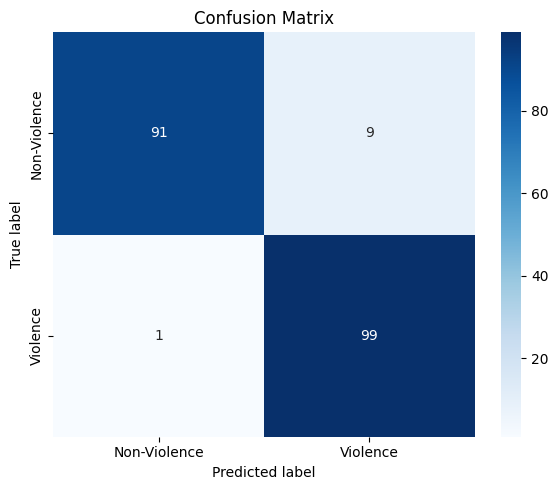

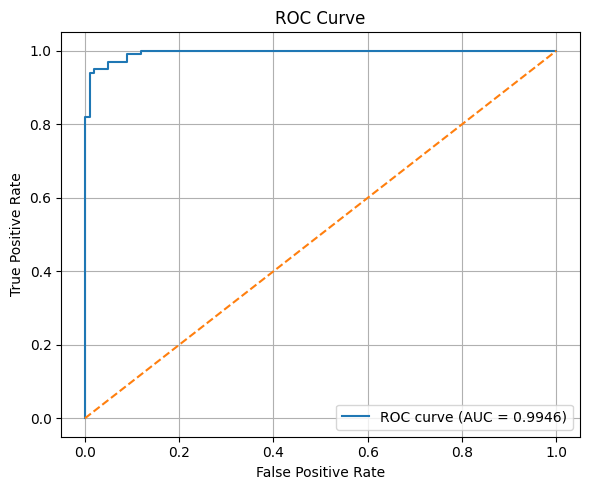


=== TEST METRICS ===
Accuracy : 0.5090
Precision: 0.5045
Recall   : 1.0000
F1-score : 0.6707
ROC AUC  : 0.7295


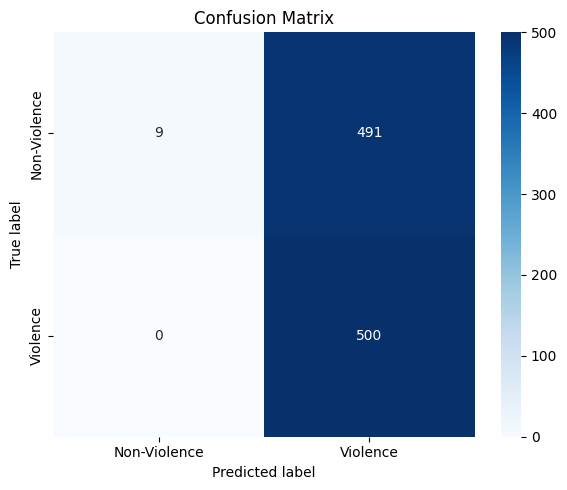

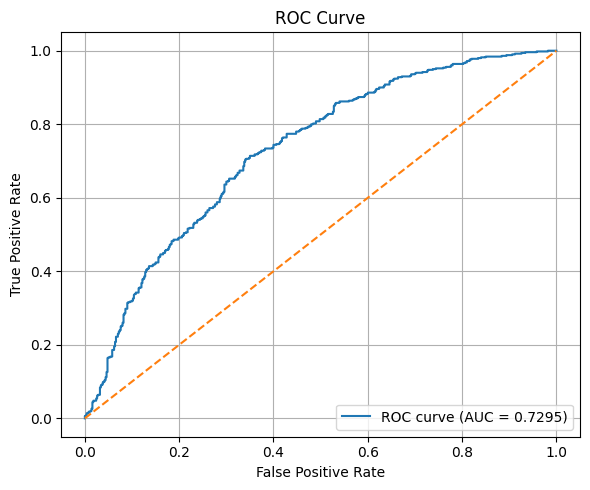


--- Scenario: Hockey_to_RLVS ---

=== Seed 44 ===


/tmp/ipykernel_24/1967065897.py:14: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()


Epoch 1/5 [Train]:   0%|          | 0/100 [00:00<?, ?it/s]

/tmp/ipykernel_24/1967065897.py:33: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
/tmp/ipykernel_24/1967065897.py:57: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Summary -> Train Acc: 0.8925, Val Acc: 0.9400


...

Summary -> Train Acc: 0.9313, Val Acc: 0.9400


Epoch 4/5 [Train]:   0%|          | 0/100 [00:00<?, ?it/s]

Summary -> Train Acc: 0.9587, Val Acc: 0.9500


Epoch 5/5 [Train]:   0%|          | 0/100 [00:00<?, ?it/s]

Summary -> Train Acc: 0.9725, Val Acc: 0.9600


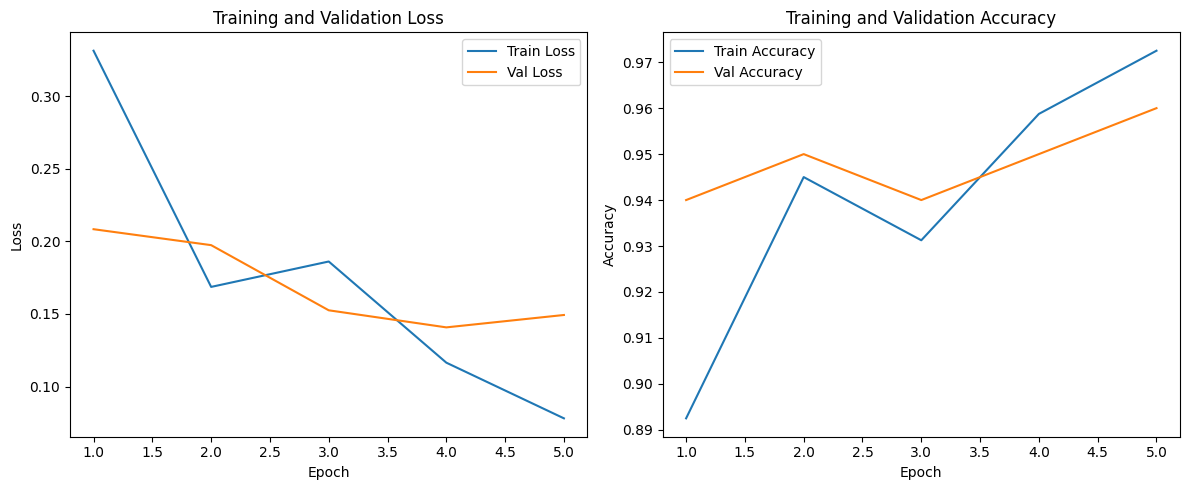


=== VAL METRICS ===
Accuracy : 0.9600
Precision: 0.9259
Recall   : 1.0000
F1-score : 0.9615
ROC AUC  : 0.9864


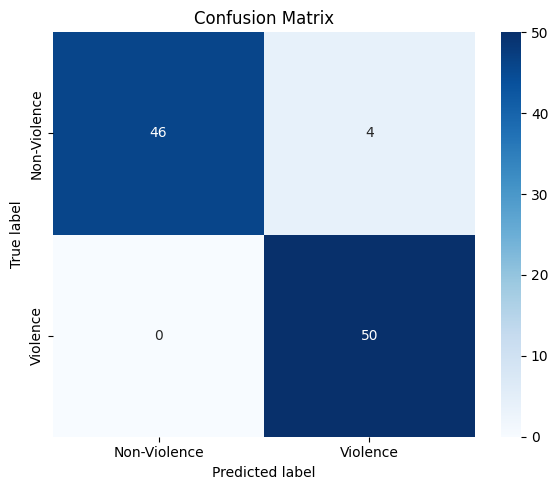

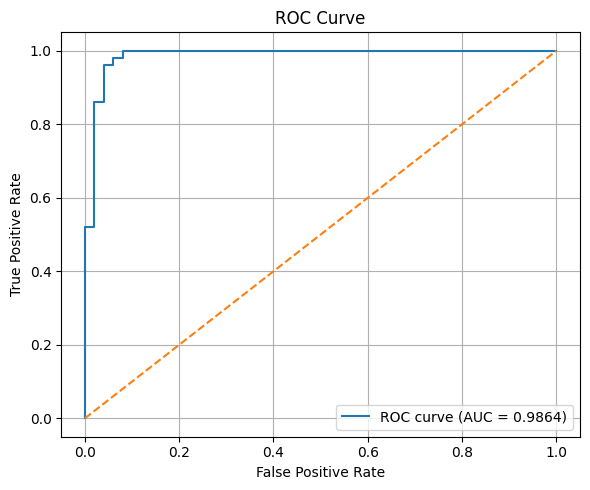

[h264 @ 0x458fa140] mb_type 104 in P slice too large at 98 31
[h264 @ 0x458fa140] error while decoding MB 98 31



=== TEST METRICS ===
Accuracy : 0.6955
Precision: 0.6799
Recall   : 0.7385
F1-score : 0.7080
ROC AUC  : 0.7547


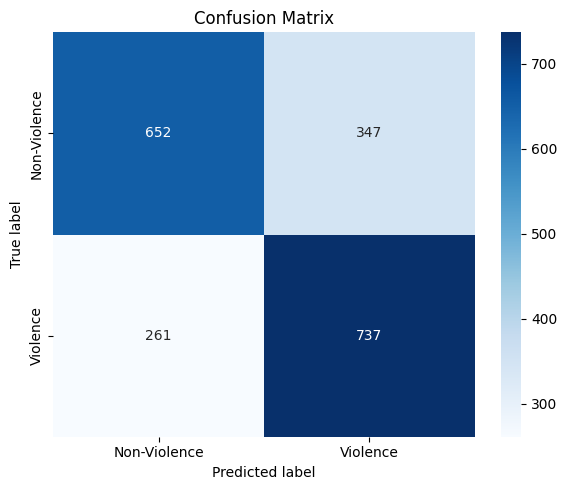

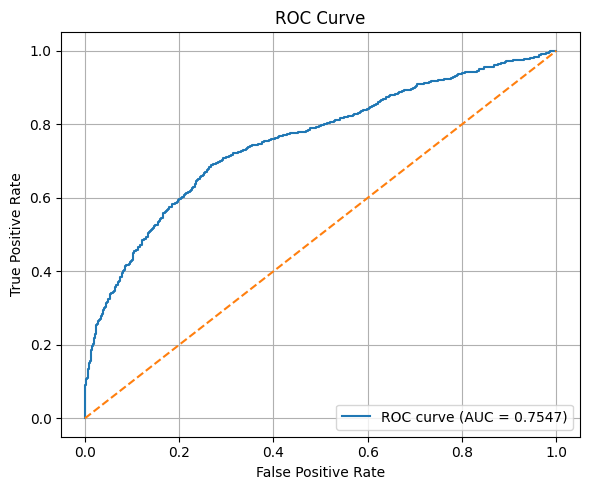

In [17]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_names = ["cnn+lstm"]
seeds = [44]
n_frames = 32
batch_size = 16

scenarios = [
    {"name": "Combined_RLVS_Hockey_to_SCVD", "train": ["rlvs","hockey"], "test": "scvd"},
    {"name": "RLVS_train", "train": ["rlvs"], "test": "rlvs"},
    {"name": "Hockey_train", "train": ["hockey"], "test": "hockey"},
    {"name": "RLVS_to_Hockey", "train": ["rlvs"], "test": "hockey"},
    {"name": "Hockey_to_RLVS", "train": ["hockey"], "test": "rlvs"},
]

all_results = {}
for model_name in model_names:
    print(f"\n\n========== MODEL: {model_name} ==========")
    for scenario in scenarios:
        scenario_name = scenario["name"]
        train_datasets = scenario["train"]
        test_dataset = scenario["test"]
        print(f"\n--- Scenario: {scenario_name} ---")
        
        results = run_scenario(
            model_name=model_name,
            train_datasets=train_datasets,
            test_dataset=test_dataset,
            device=device,
            epochs=5,
            n_frames=n_frames,
            batch_size=batch_size,
            seeds=seeds
        )
        all_results[(model_name, scenario_name)] = results